In [4]:
import pandas as pd
import numpy as np

import scipy.stats as st

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
df_sample = pd.read_csv('Sample Prediction Dataset.csv')
df_test = pd.read_csv('Test Data.csv')
df = pd.read_csv('Training Data.csv')

In [8]:
# Display the first 5 rows
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


## There is No Null Data

In [12]:
df.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [14]:
df.select_dtypes('object').describe()

,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE
count,252000,252000,252000,252000,252000,252000
unique,2,3,2,51,317,29
top,single,rented,no,Physician,Vijayanagaram,Uttar_Pradesh
freq,226272,231898,176000,5957,1259,28400


In [16]:
def load(read, info=True):
    import io

    if info:
        if len(read) > 0:
            print('Data Imported')
            print('Dimesion Table -----------','\n')
            print('Row:',read.shape[0],'\n''Column:',read.shape[1])

            print('DTypes------------------------------------------')
            if len(read.select_dtypes('object').columns)>0:
                print('Count Data Object:',len(read.select_dtypes('object').columns),'\n''Column List:',
                      read.select_dtypes("object").columns.tolist(),'\n')
            else:
                print('No Data Object')

            if len(read.select_dtypes('integer').columns)>0:
                print('Count Data integer:',len(read.select_dtypes('integer').columns),'\n''Column List:',
                      read.select_dtypes("integer").columns.tolist(), '\n')
            else:
                print('No Data Integer')

            if len(read.select_dtypes('float').columns)>0:
                print('Count Data float:',len(read.select_dtypes('float').columns),'\n''Column List:',
                      read.select_dtypes("float").columns.tolist(), '\n')
            else:
                print('No Data float')

            if len(read.select_dtypes('bool').columns)>0:
                print('Count Data bool:',len(read.select_dtypes('bool').columns),'\n''Column List:',
                      read.select_dtypes("bool").columns.tolist(), '\n')
            else:
                print('No Data boolean')

load(df)

Data Imported
Dimesion Table ----------- 

Row: 252000 
Column: 13
DTypes------------------------------------------
Count Data Object: 6 
Column List: ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE'] 

Count Data integer: 7 
Column List: ['Id', 'Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag'] 

No Data float
No Data boolean


In [18]:
# Check for Inconsistent Entries
# Example: Check for unique values in categorical columns
categorical_cols = ["Married/Single", "House_Ownership", "Car_Ownership", "CITY", "STATE", "Profession"]
for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("-----------------------------")

Unique values in Married/Single:
['single' 'married']
-----------------------------
Unique values in House_Ownership:
['rented' 'norent_noown' 'owned']
-----------------------------
Unique values in Car_Ownership:
['no' 'yes']
-----------------------------
Unique values in CITY:
['Rewa' 'Parbhani' 'Alappuzha' 'Bhubaneswar' 'Tiruchirappalli[10]'
 'Jalgaon' 'Tiruppur' 'Jamnagar' 'Kota[6]' 'Karimnagar' 'Hajipur[31]'
 'Adoni' 'Erode[17]' 'Kollam' 'Madurai' 'Anantapuram[24]' 'Kamarhati'
 'Bhusawal' 'Sirsa' 'Amaravati' 'Secunderabad' 'Ahmedabad' 'Ajmer'
 'Ongole' 'Miryalaguda' 'Ambattur' 'Indore' 'Pondicherry' 'Shimoga'
 'Chennai' 'Gulbarga' 'Khammam' 'Saharanpur' 'Gopalpur' 'Amravati' 'Udupi'
 'Howrah' 'Aurangabad[39]' 'Hospet' 'Shimla' 'Khandwa' 'Bidhannagar'
 'Bellary' 'Danapur' 'Purnia[26]' 'Bijapur' 'Patiala' 'Malda' 'Sagar'
 'Durgapur' 'Junagadh' 'Singrauli' 'Agartala' 'Thanjavur' 'Hindupur'
 'Naihati' 'North_Dumdum' 'Panchkula' 'Anantapur' 'Serampore' 'Bathinda'
 'Nadiad' 'Kanpur' 'Ha

In [20]:
# Cleaning CITY column (removing unwanted characters like [10], [6], etc.)
df["CITY"] = df["CITY"].str.replace(r"\[\d+\]", "", regex=True).str.strip()
df_test["CITY"] = df_test["CITY"].str.replace(r"\[\d+\]", "", regex=True).str.strip()

# Cleaning STATE column (removing unwanted characters like [5], etc.)
df["STATE"] = df["STATE"].str.replace(r"\[\d+\]", "", regex=True).str.strip()
df_test["STATE"] = df_test["STATE"].str.replace(r"\[\d+\]", "", regex=True).str.strip()

# Convert all object (string) columns to lowercase
df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)
df_test = df_test.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [22]:
categorical_cols = ["Married/Single", "House_Ownership", "Car_Ownership", "CITY", "STATE", "Profession"]
for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("-----------------------------")

Unique values in Married/Single:
['single' 'married']
-----------------------------
Unique values in House_Ownership:
['rented' 'norent_noown' 'owned']
-----------------------------
Unique values in Car_Ownership:
['no' 'yes']
-----------------------------
Unique values in CITY:
['rewa' 'parbhani' 'alappuzha' 'bhubaneswar' 'tiruchirappalli' 'jalgaon'
 'tiruppur' 'jamnagar' 'kota' 'karimnagar' 'hajipur' 'adoni' 'erode'
 'kollam' 'madurai' 'anantapuram' 'kamarhati' 'bhusawal' 'sirsa'
 'amaravati' 'secunderabad' 'ahmedabad' 'ajmer' 'ongole' 'miryalaguda'
 'ambattur' 'indore' 'pondicherry' 'shimoga' 'chennai' 'gulbarga'
 'khammam' 'saharanpur' 'gopalpur' 'amravati' 'udupi' 'howrah'
 'aurangabad' 'hospet' 'shimla' 'khandwa' 'bidhannagar' 'bellary'
 'danapur' 'purnia' 'bijapur' 'patiala' 'malda' 'sagar' 'durgapur'
 'junagadh' 'singrauli' 'agartala' 'thanjavur' 'hindupur' 'naihati'
 'north_dumdum' 'panchkula' 'anantapur' 'serampore' 'bathinda' 'nadiad'
 'kanpur' 'haridwar' 'berhampur' 'jamshe

## Drop the ID

In [24]:
df_train = df.drop('Id', axis=1) if len(df['Id']) == len(df) else df
df_train.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1303834,23,3,single,rented,no,mechanical_engineer,rewa,madhya_pradesh,3,13,0
1,7574516,40,10,single,rented,no,software_developer,parbhani,maharashtra,9,13,0
2,3991815,66,4,married,rented,no,technical_writer,alappuzha,kerala,4,10,0
3,6256451,41,2,single,rented,yes,software_developer,bhubaneswar,odisha,2,12,1
4,5768871,47,11,single,rented,no,civil_servant,tiruchirappalli,tamil_nadu,3,14,1


In [26]:
df_tes = df_test.drop('ID', axis=1) if len(df_test['ID']) == len(df_test) else df_test
df_tes.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,7393090,59,19,single,rented,no,geologist,malda,west bengal,4,13
1,1215004,25,5,single,rented,no,firefighter,jalna,maharashtra,5,10
2,8901342,50,12,single,rented,no,lawyer,thane,maharashtra,9,14
3,1944421,49,9,married,rented,yes,analyst,latur,maharashtra,3,12
4,13429,25,18,single,rented,yes,comedian,berhampore,west bengal,13,11


In [28]:
def columns_less_than_10_unique(df):
    columns_less_than_10_unique = [col for col in df.columns if df[col].nunique() < 10]
    df_less10 = df[columns_less_than_10_unique].copy()
    df_less10_with_y = df_less10.copy()
    df_less10 = df_less10.drop(df_less10.columns[-1], axis=1)
    return df_less10, df_less10_with_y

t, t_with_y = columns_less_than_10_unique(df)

t.head()

,Married/Single,House_Ownership,Car_Ownership,CURRENT_HOUSE_YRS
0,single,rented,no,13
1,single,rented,no,13
2,married,rented,no,10
3,single,rented,yes,12
4,single,rented,no,14


<h1>Visualize</h1>

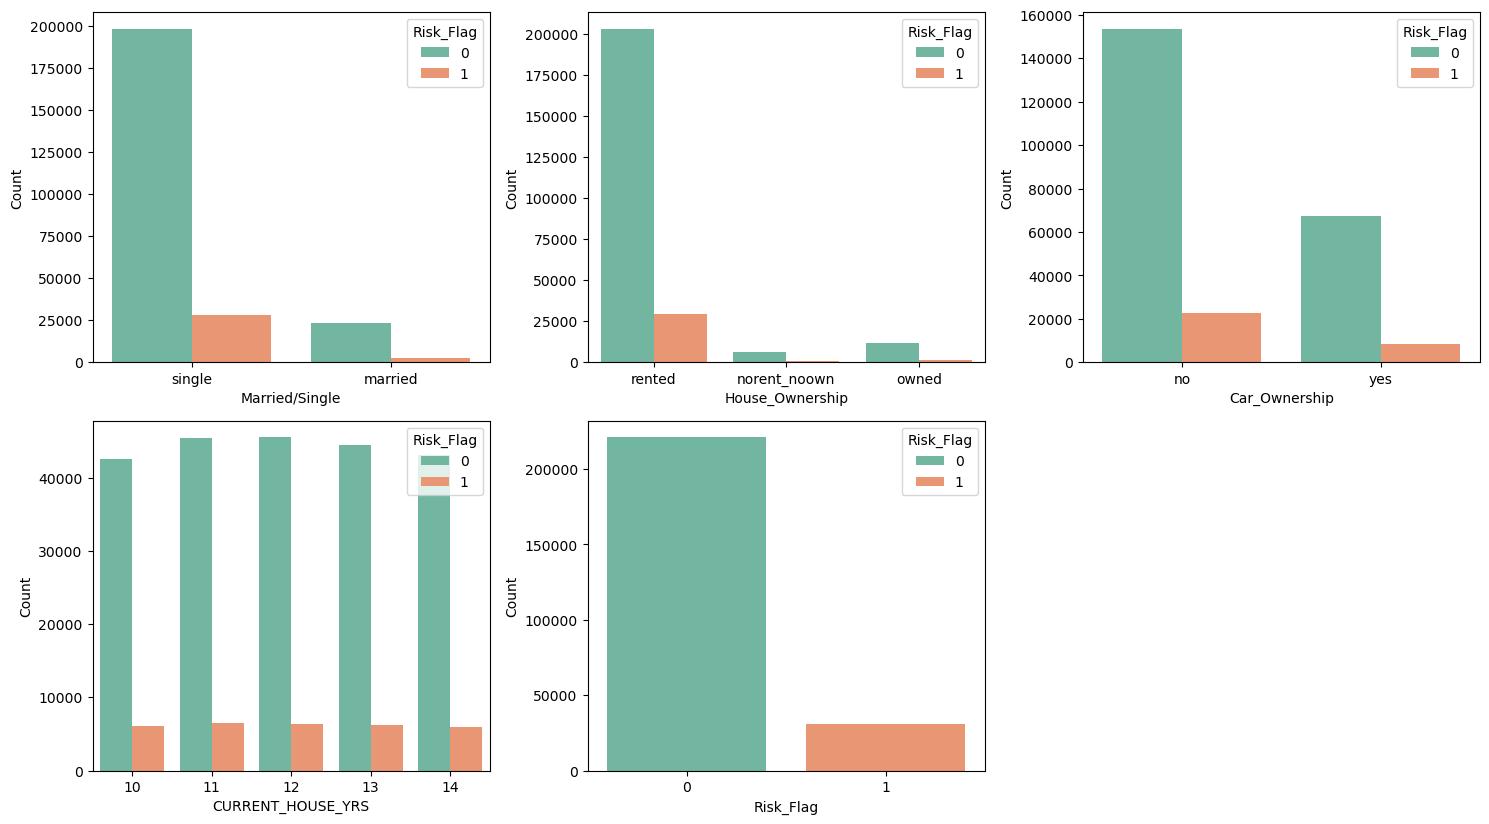

In [30]:
def plot_subplots_cat(df, divider_col):
    num_plots = len(df.columns)
    num_rows = (num_plots + 1) // 2

    fig = plt.figure(figsize=(15, 12))

    for i, column in enumerate(df.columns, start=1):
        ax = fig.add_subplot(num_rows, 3, i)
        sns.countplot(x=column, palette='Set2', hue=divider_col, data=df, ax=ax)
        plt.xlabel(column)
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

plot_subplots_cat(t_with_y, t_with_y.columns[-1])

### 1. Married Status vs. Risk Flag
Mayoritas peminjam yang mengajukan kredit adalah single, dengan jumlah yang jauh lebih besar dibandingkan yang menikah. Namun, proporsi peminjam berisiko (Risk_Flag = 1) terlihat lebih tinggi pada kelompok single dibandingkan yang menikah, yang bisa mengindikasikan bahwa status pernikahan berpengaruh pada stabilitas keuangan seseorang.

### 2. House Ownership vs. Risk Flag
Sebagian besar peminjam tinggal di rumah sewa, dan mereka juga memiliki jumlah peminjam berisiko yang lebih tinggi dibandingkan dengan mereka yang memiliki rumah sendiri. Hal ini dapat menunjukkan bahwa memiliki rumah sendiri berpotensi menurunkan risiko kredit macet, karena kepemilikan aset bisa menjadi indikator kestabilan keuangan.

### 3. Car Ownership vs. Risk Flag
Peminjam yang tidak memiliki mobil jauh lebih banyak dibandingkan mereka yang memiliki mobil. Namun, dalam kedua kelompok, persentase peminjam berisiko tampak relatif serupa. Ini mengindikasikan bahwa kepemilikan mobil bukan faktor utama dalam menentukan risiko kredit, meskipun bisa menjadi salah satu pertimbangan dalam penilaian kredit.

### 4. Current House Years vs. Risk Flag
Rentang lama tinggal di rumah saat ini (10-14 tahun) tampaknya tidak memiliki variasi yang signifikan terhadap jumlah peminjam berisiko. Hal ini menunjukkan bahwa lamanya menetap di satu lokasi tidak secara langsung berkorelasi dengan tingkat risiko peminjam.

### 5. Risk Flag Distribution
Sebagian besar peminjam dalam dataset memiliki Risk_Flag = 0, artinya mereka tergolong dalam kelompok yang lebih aman untuk diberikan kredit. Namun, proporsi peminjam berisiko masih cukup besar, yang menunjukkan bahwa tetap diperlukan mekanisme penyaringan kredit yang kuat untuk mengurangi risiko gagal bayar.

## OUTLIERS

In [29]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Income             252000 non-null  int64 
 1   Age                252000 non-null  int64 
 2   Experience         252000 non-null  int64 
 3   Married/Single     252000 non-null  object
 4   House_Ownership    252000 non-null  object
 5   Car_Ownership      252000 non-null  object
 6   Profession         252000 non-null  object
 7   CITY               252000 non-null  object
 8   STATE              252000 non-null  object
 9   CURRENT_JOB_YRS    252000 non-null  int64 
 10  CURRENT_HOUSE_YRS  252000 non-null  int64 
 11  Risk_Flag          252000 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 23.1+ MB


In [30]:
# Detecting Outliers using IQR
numeric_cols = ["Income", "Age", "Experience", "CURRENT_JOB_YRS", "CURRENT_HOUSE_YRS"]
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in Income: 0
Outliers in Age: 0
Outliers in Experience: 0
Outliers in CURRENT_JOB_YRS: 0
Outliers in CURRENT_HOUSE_YRS: 0


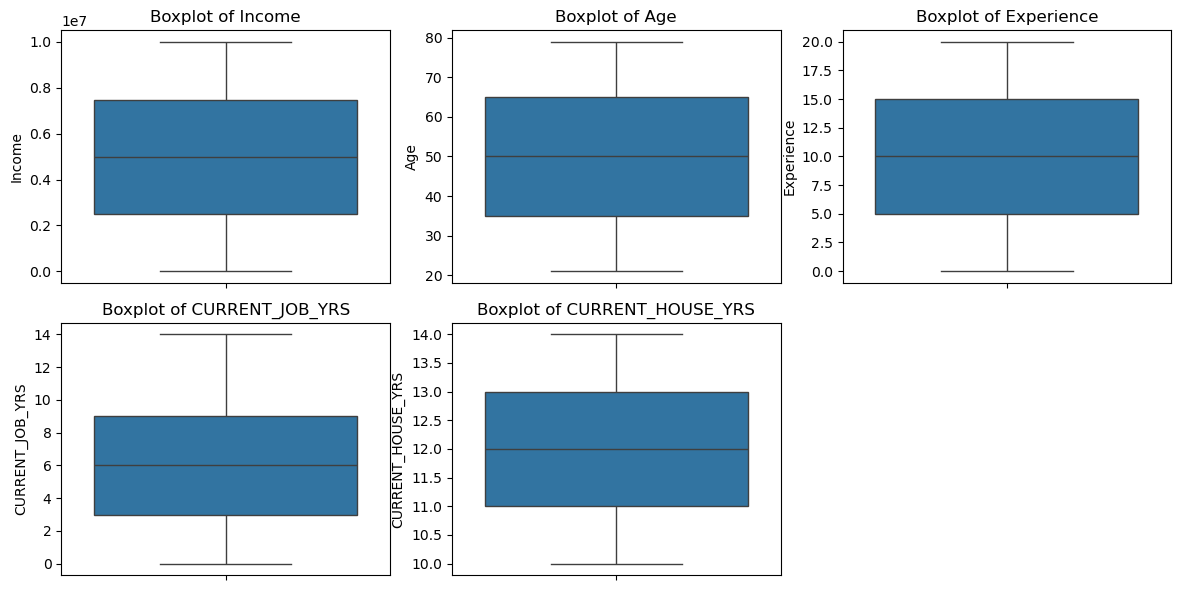

In [32]:
# Visualizing Outliers using Boxplots
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [35]:
# Summary Statistics
descriptive_stats = df_train.describe()
print("Descriptive Statistics:")
print(descriptive_stats)

Descriptive Statistics:
             Income            Age     Experience  CURRENT_JOB_YRS  \
count  2.520000e+05  252000.000000  252000.000000    252000.000000   
mean   4.997117e+06      49.954071      10.084437         6.333877   
std    2.878311e+06      17.063855       6.002590         3.647053   
min    1.031000e+04      21.000000       0.000000         0.000000   
25%    2.503015e+06      35.000000       5.000000         3.000000   
50%    5.000694e+06      50.000000      10.000000         6.000000   
75%    7.477502e+06      65.000000      15.000000         9.000000   
max    9.999938e+06      79.000000      20.000000        14.000000   

       CURRENT_HOUSE_YRS      Risk_Flag  
count      252000.000000  252000.000000  
mean           11.997794       0.123000  
std             1.399037       0.328438  
min            10.000000       0.000000  
25%            11.000000       0.000000  
50%            12.000000       0.000000  
75%            13.000000       0.000000  
max      

## Feature Engineering

In [34]:
## 1. Age_Group
def categorize_age(age):
    if age < 18:
        return "young"
    elif age < 40:
        return "middle age"
    else:
        return "old"
df_train['age_group'] = df_train['Age'].apply(categorize_age)

# 2. Job Stability
df_train['job_stability'] = df_train['CURRENT_JOB_YRS'] / df_train['Age']

# 3. Home Stability
df_train['home_stability'] = df_train['CURRENT_HOUSE_YRS'] / df_train['Age']

# 4. Financial Stability Score (arbitrary formula)
df_train['financial_stability'] = df_train['Income'] * (df_train['Car_Ownership'].map({'yes': 1, 'no': 0}) + 1) * (df_train['House_Ownership'].map({'owned': 1, 'rented': 0.5, 'norent_noown': 0}))

# 5. Income
q1=df['Income'].quantile(0.25)
q3= df['Income'].quantile(0.75)
def income_segment(income):

    if income < q1:
        return "low"
    elif income > q3:
        return "high"
    else:
        return "medium"
df_train["income_segment"] = df_train["Income"].apply(income_segment)
df_train.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,age_group,job_stability,home_stability,financial_stability,income_segment
0,1303834,23,3,single,rented,no,mechanical_engineer,rewa,madhya_pradesh,3,13,0,middle age,0.130435,0.565217,651917.0,low
1,7574516,40,10,single,rented,no,software_developer,parbhani,maharashtra,9,13,0,old,0.225000,0.325000,3787258.0,high
2,3991815,66,4,married,rented,no,technical_writer,alappuzha,kerala,4,10,0,old,0.060606,0.151515,1995907.5,medium
3,6256451,41,2,single,rented,yes,software_developer,bhubaneswar,odisha,2,12,1,old,0.048780,0.292683,6256451.0,medium
4,5768871,47,11,single,rented,no,civil_servant,tiruchirappalli,tamil_nadu,3,14,1,old,0.063830,0.297872,2884435.5,medium


In [36]:
# List of new features
new_features = ["age_group", "job_stability", "home_stability","financial_stability","income_segment"]

# Check if all new features exist in df_train
missing_features = [col for col in new_features if col not in df_train.columns]
if missing_features:
    raise KeyError(f"These new features are missing: {missing_features}")

# Display the first 20 rows of the new features
print(df_train[new_features].head(20))

     age_group  job_stability  home_stability  financial_stability  \
0   middle age       0.130435        0.565217             651917.0   
1          old       0.225000        0.325000            3787258.0   
2          old       0.060606        0.151515            1995907.5   
3          old       0.048780        0.292683            6256451.0   
4          old       0.063830        0.297872            2884435.5   
5          old       0.000000        0.187500            3457968.5   
6          old       0.137931        0.206897            1977486.5   
7   middle age       0.060606        0.424242             853086.0   
8   middle age       0.458333        0.458333            7566849.0   
9   middle age       0.217391        0.565217            4482423.0   
10         old       0.089744        0.153846            2317340.0   
11  middle age       0.181818        0.636364            3311631.5   
12  middle age       0.321429        0.428571            4560494.0   
13         old      

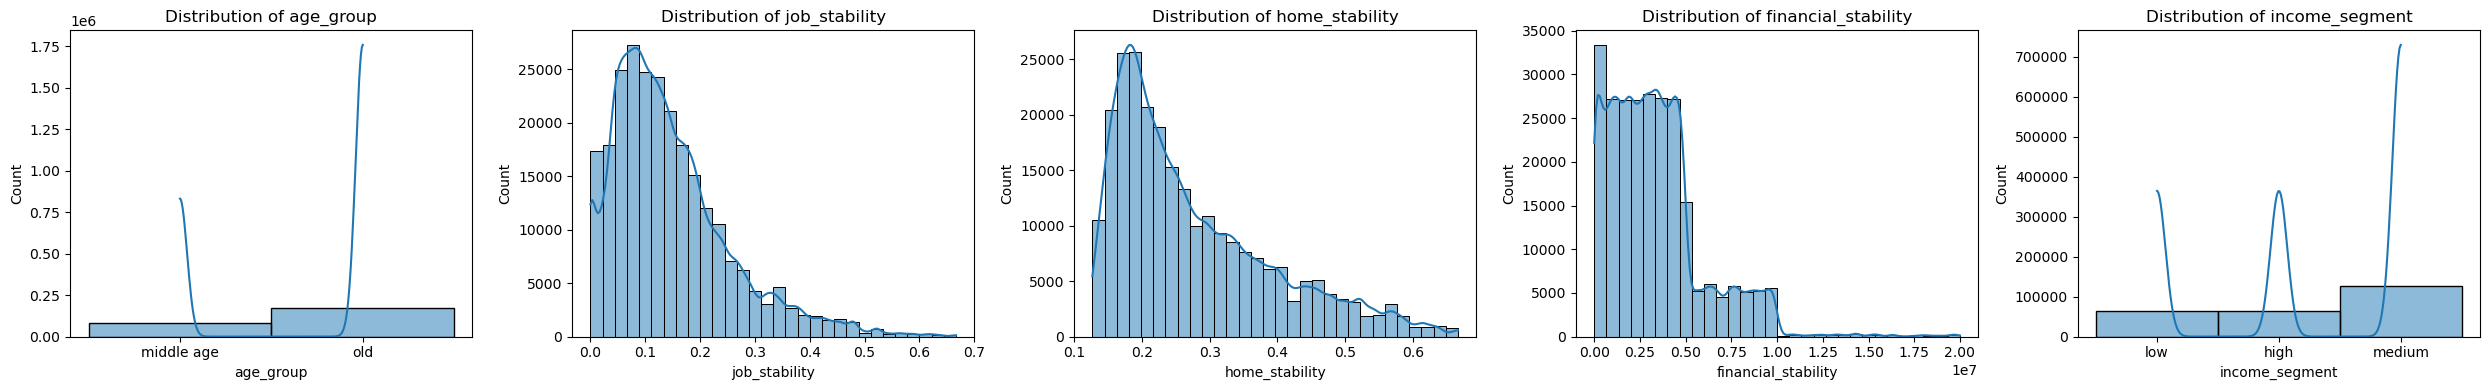

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure new_features is defined
new_features = ["age_group", "job_stability", "home_stability","financial_stability","income_segment"]

num_features = len(new_features)
plt.figure(figsize=(5 * num_features, 4))  # Adjust figure width

for i, feature in enumerate(new_features):
    plt.subplot(1, num_features, i + 1)  # Dynamically set number of subplots
    sns.histplot(df_train[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()


In [40]:
df_train.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,age_group,job_stability,home_stability,financial_stability,income_segment
0,1303834,23,3,single,rented,no,mechanical_engineer,rewa,madhya_pradesh,3,13,0,middle age,0.130435,0.565217,651917.0,low
1,7574516,40,10,single,rented,no,software_developer,parbhani,maharashtra,9,13,0,old,0.225000,0.325000,3787258.0,high
2,3991815,66,4,married,rented,no,technical_writer,alappuzha,kerala,4,10,0,old,0.060606,0.151515,1995907.5,medium
3,6256451,41,2,single,rented,yes,software_developer,bhubaneswar,odisha,2,12,1,old,0.048780,0.292683,6256451.0,medium
4,5768871,47,11,single,rented,no,civil_servant,tiruchirappalli,tamil_nadu,3,14,1,old,0.063830,0.297872,2884435.5,medium


In [45]:
print(df_train.head())

    Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0  1303834   23           3         single          rented            no   
1  7574516   40          10         single          rented            no   
2  3991815   66           4        married          rented            no   
3  6256451   41           2         single          rented           yes   
4  5768871   47          11         single          rented            no   

            Profession             CITY           STATE  CURRENT_JOB_YRS  \
0  mechanical_engineer             rewa  madhya_pradesh                3   
1   software_developer         parbhani     maharashtra                9   
2     technical_writer        alappuzha          kerala                4   
3   software_developer      bhubaneswar          odisha                2   
4        civil_servant  tiruchirappalli      tamil_nadu                3   

   CURRENT_HOUSE_YRS  Risk_Flag   age_group  job_stability  home_stability  \
0       

Data shape: (252000, 17)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Income               252000 non-null  int64  
 1   Age                  252000 non-null  int64  
 2   Experience           252000 non-null  int64  
 3   Married/Single       252000 non-null  object 
 4   House_Ownership      252000 non-null  object 
 5   Car_Ownership        252000 non-null  object 
 6   Profession           252000 non-null  object 
 7   CITY                 252000 non-null  object 
 8   STATE                252000 non-null  object 
 9   CURRENT_JOB_YRS      252000 non-null  int64  
 10  CURRENT_HOUSE_YRS    252000 non-null  int64  
 11  Risk_Flag            252000 non-null  int64  
 12  age_group            252000 non-null  object 
 13  job_stability        252000 non-null  float64
 14  home_stability       252000 non

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Best parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}

Tuned Model Performance:
Best CV ROC AUC: 0.9390
Test Accuracy: 0.8949
Test ROC AUC: 0.9373
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



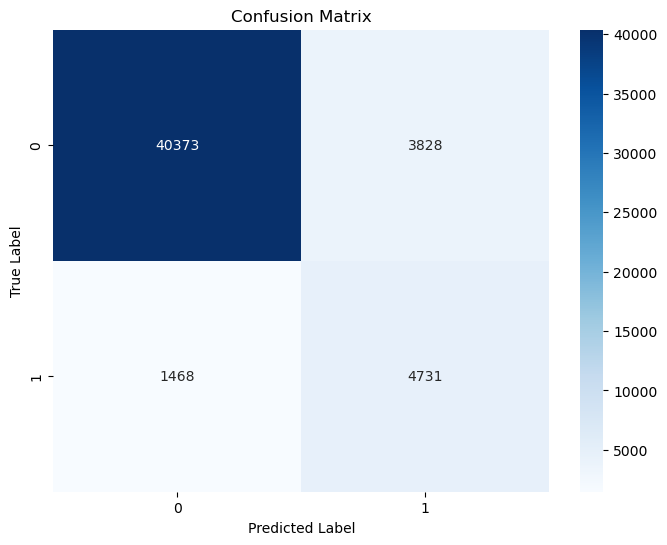

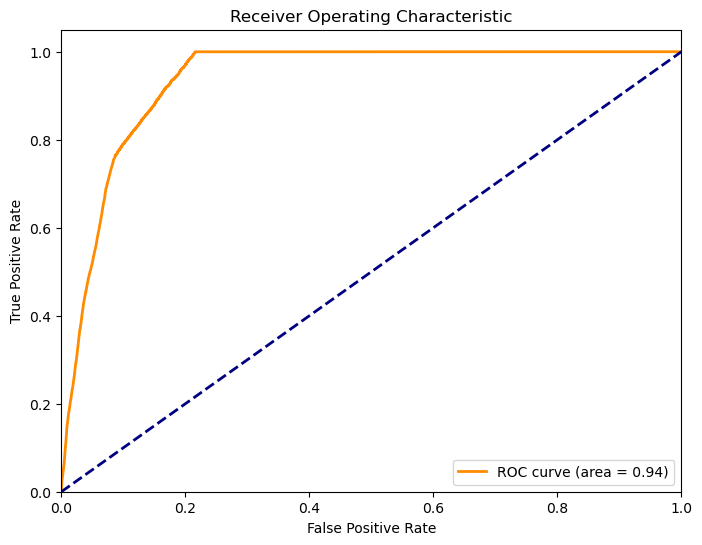

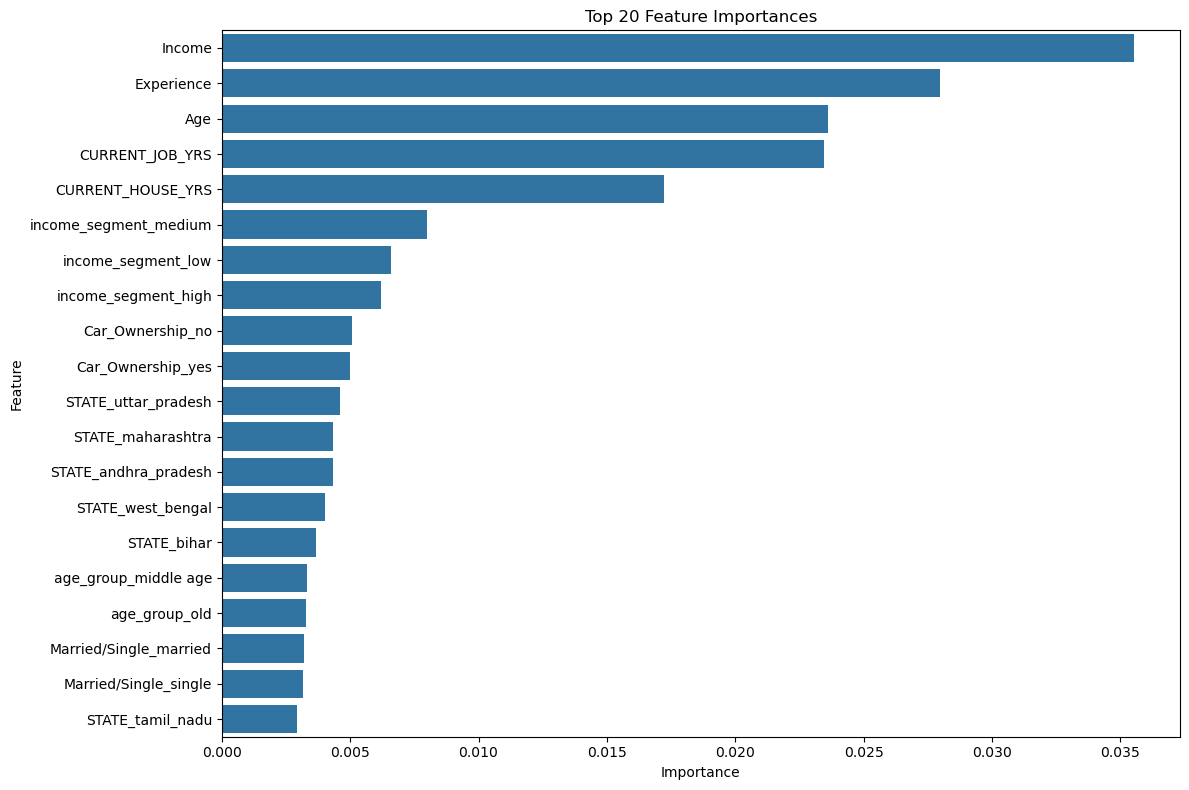


Top 10 most important features:
                     Feature  Importance
0                     Income    0.035544
2                 Experience    0.027987
1                        Age    0.023602
3            CURRENT_JOB_YRS    0.023443
4          CURRENT_HOUSE_YRS    0.017204
35037  income_segment_medium    0.007998
35036     income_segment_low    0.006588
35035    income_segment_high    0.006220
10          Car_Ownership_no    0.005084
11         Car_Ownership_yes    0.004983

Best model saved as 'best_risk_prediction_model.pkl'


In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
# Let's first examine the data
print("Data shape:", df_train.shape)
print("\nData info:")
print(df_train.info())
print("\nData sample:")
print(df_train.head())
print("\nTarget variable distribution:")
print(df_train['Risk_Flag'].value_counts(normalize=True))

# Split features and target
X = df_train.drop('Risk_Flag', axis=1)
y = df_train['Risk_Flag']

# Identify categorical and numerical features
cat_features = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 
                'CITY', 'STATE', 'age_group', 'job_stability', 'home_stability', 
                'financial_stability', 'income_segment']
num_features = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Function to evaluate and compare different models
def evaluate_models(X_train, X_test, y_train, y_test):
    # Define models to evaluate
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Create pipeline with preprocessing
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        # Perform cross-validation
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
        
        # Fit model on training data
        pipeline.fit(X_train, y_train)
        
        # Predict on test data
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Store results
        results[name] = {
            'model': pipeline,
            'cv_scores': cv_scores,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'accuracy': accuracy,
            'roc_auc': roc_auc
        }
        
        print(f"\n{name}:")
        print(f"Cross-validation ROC AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test ROC AUC: {roc_auc:.4f}")
        print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    
    return results

# Evaluate baseline models
print("Evaluating baseline models...")
baseline_results = evaluate_models(X_train, X_test, y_train, y_test)

# Select the best model for hyperparameter tuning
best_model_name = max(baseline_results, key=lambda x: baseline_results[x]['cv_mean'])
print(f"\nBest model: {best_model_name} with ROC AUC: {baseline_results[best_model_name]['cv_mean']:.4f}")

# Define hyperparameter search spaces for each model type
param_grids = {
    'Logistic Regression': {
        'classifier__C': np.logspace(-4, 4, 10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__class_weight': [None, 'balanced']
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__subsample': [0.8, 0.9, 1.0]
    }
}

# Create pipeline with the best model
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', baseline_results[best_model_name]['model'].named_steps['classifier'])
])

# Perform hyperparameter tuning with cross-validation
print(f"\nPerforming hyperparameter tuning for {best_model_name}...")
grid_search = RandomizedSearchCV(
    best_pipeline,
    param_distributions=param_grids[best_model_name],
    n_iter=20,  # Number of parameter settings sampled
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Print best parameters
print("\nBest parameters:")
print(grid_search.best_params_)

# Evaluate the tuned model
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTuned Model Performance:")
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Feature importance for tree-based models
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    # Extract feature names from the preprocessor
    preprocessor_fitted = best_model.named_steps['preprocessor']
    feature_names = []
    for name, trans, features in preprocessor_fitted.transformers_:
        if name == 'num':
            feature_names.extend(features)
        elif name == 'cat':
            # Get one-hot encoded feature names
            ohe = trans
            for i, feature in enumerate(features):
                categories = ohe.categories_[i]
                feature_names.extend([f"{feature}_{c}" for c in categories])
    
    # Get feature importances
    importances = best_model.named_steps['classifier'].feature_importances_
    
    # Make sure feature_names and importances have the same length
    if len(feature_names) == len(importances):
        # Create a DataFrame of feature importances
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        # Plot the top 20 features
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
        plt.title('Top 20 Feature Importances')
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 most important features:")
        print(feature_importance_df.head(10))

# Save the trained model
import joblib
joblib.dump(best_model, 'best_risk_prediction_model.pkl')
print("\nBest model saved as 'best_risk_prediction_model.pkl'")

Performance at different thresholds:
Threshold  Precision  Recall     F1 Score   Accuracy  
0.10       0.3941     0.9987     0.5651     0.8110    
0.15       0.3984     0.9866     0.5676     0.8151    
0.20       0.4165     0.9443     0.5781     0.8304    
0.25       0.4547     0.8750     0.5984     0.8556    
0.30       0.5023     0.8142     0.6213     0.8779    
0.35       0.5337     0.7822     0.6345     0.8891    
0.40       0.5466     0.7680     0.6386     0.8931    
0.45       0.5512     0.7635     0.6402     0.8945    
0.50       0.5528     0.7632     0.6411     0.8949    
0.55       0.5529     0.7622     0.6409     0.8949    
0.60       0.5538     0.7583     0.6401     0.8951    
0.65       0.5548     0.7572     0.6404     0.8954    


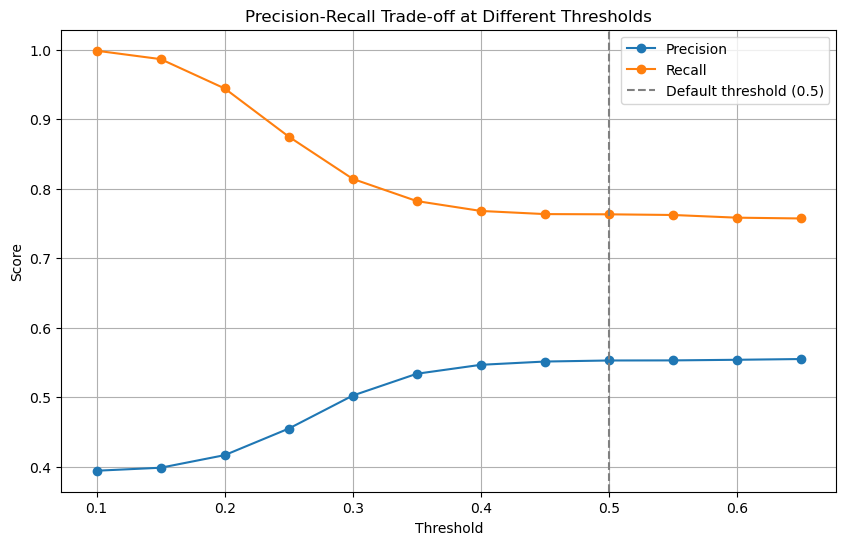


Classification Report with threshold = 0.3:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     44201
           1       0.50      0.81      0.62      6199

    accuracy                           0.88     50400
   macro avg       0.74      0.85      0.77     50400
weighted avg       0.91      0.88      0.89     50400



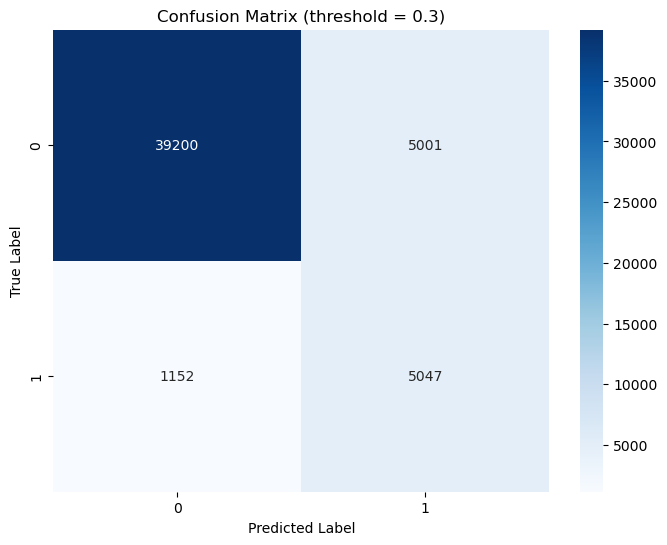

Calibrated model saved as 'calibrated_risk_prediction_model.pkl' with threshold = 0.3


In [44]:
# Load your saved model
import joblib

# Load the model
best_model = joblib.load('best_risk_prediction_model.pkl')

# Function to calibrate the model for higher sensitivity
def calibrate_model_sensitivity(model, X_test, y_test, threshold=0.5):
    """
    Calibrate model by adjusting prediction threshold to increase sensitivity.
    
    Parameters:
    -----------
    model : trained model
        The fitted model with predict_proba method
    X_test : array-like
        Test features
    y_test : array-like
        True labels
    threshold : float, default=0.5
        New threshold value (lower = more sensitive to positive class)
        
    Returns:
    --------
    threshold_metrics : dict
        Dictionary with performance metrics at different thresholds
    best_threshold : float
        Suggested threshold based on F1 score
    """
    from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, precision_score
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Get probability predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Test different thresholds
    thresholds = np.arange(0.1, 0.7, 0.05)
    threshold_metrics = {}
    
    print("Performance at different thresholds:")
    print("{:<10} {:<10} {:<10} {:<10} {:<10}".format(
        "Threshold", "Precision", "Recall", "F1 Score", "Accuracy"))
    
    for t in thresholds:
        # Apply threshold to get binary predictions
        y_pred_t = (y_proba >= t).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_test, y_pred_t)
        recall = recall_score(y_test, y_pred_t)
        f1 = f1_score(y_test, y_pred_t)
        accuracy = (y_pred_t == y_test).mean()
        
        threshold_metrics[t] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy
        }
        
        print("{:<10.2f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
            t, precision, recall, f1, accuracy))
    
    # Plot precision-recall trade-off
    plt.figure(figsize=(10, 6))
    plt.plot([t for t in threshold_metrics], 
             [threshold_metrics[t]['precision'] for t in threshold_metrics], 
             marker='o', label='Precision')
    plt.plot([t for t in threshold_metrics], 
             [threshold_metrics[t]['recall'] for t in threshold_metrics], 
             marker='o', label='Recall')
    plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision-Recall Trade-off at Different Thresholds')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Find threshold that maximizes F1 score (balanced precision and recall)
    best_f1 = 0
    best_threshold = 0.5
    
    for t in threshold_metrics:
        if threshold_metrics[t]['f1'] > best_f1:
            best_f1 = threshold_metrics[t]['f1']
            best_threshold = t
    
    # Use provided threshold if specified
    if threshold != 0.5:
        best_threshold = threshold
        
    # Apply the selected threshold
    y_pred_new = (y_proba >= best_threshold).astype(int)
    
    # Show classification report with new threshold
    print(f"\nClassification Report with threshold = {best_threshold}:")
    print(classification_report(y_test, y_pred_new))
    
    # Show confusion matrix with new threshold
    cm = confusion_matrix(y_test, y_pred_new)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (threshold = {best_threshold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return threshold_metrics, best_threshold

# Use the function to calibrate the model
# You'll need to load the test data as well
threshold_metrics, best_threshold = calibrate_model_sensitivity(best_model, X_test, y_test, threshold=0.3)  # Try 0.3 for higher sensitivity

# Create a wrapper class to apply the threshold
class ThresholdClassifier:
    def __init__(self, base_classifier, threshold=0.5):
        self.base_classifier = base_classifier
        self.threshold = threshold
        
    def predict(self, X):
        # Use the calibrated threshold for predictions
        y_proba = self.base_classifier.predict_proba(X)[:, 1]
        return (y_proba >= self.threshold).astype(int)
    
    def predict_proba(self, X):
        # Pass through the probability predictions
        return self.base_classifier.predict_proba(X)

# Create a calibrated model
calibrated_model = ThresholdClassifier(best_model, threshold=best_threshold)

# Save the calibrated model
joblib.dump(calibrated_model, 'calibrated_risk_prediction_model.pkl')
print(f"Calibrated model saved as 'calibrated_risk_prediction_model.pkl' with threshold = {best_threshold}")


Testing strategy: No Resampling

Random Forest with No Resampling Performance:
Accuracy: 0.8948
ROC AUC: 0.9373
Average Precision (PR AUC): 0.5913
F1 Score: 0.6408
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



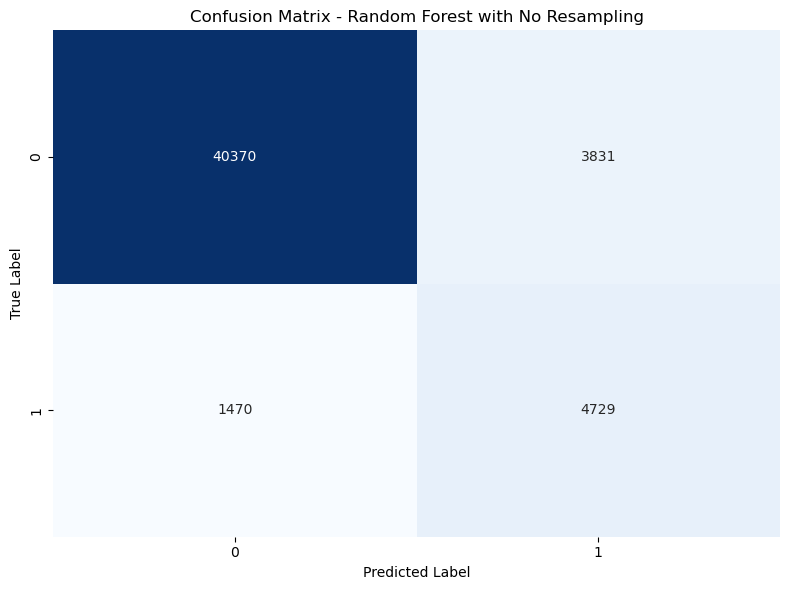

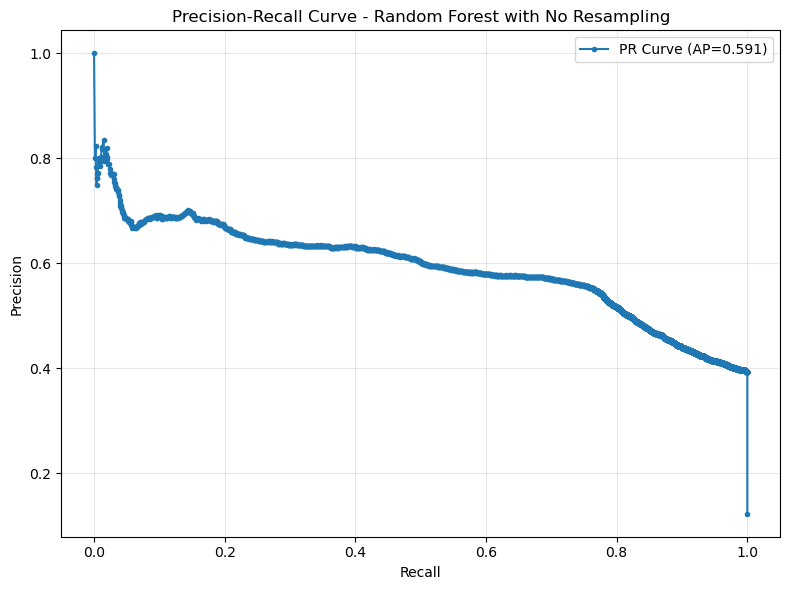


Testing strategy: SMOTE

Random Forest with SMOTE Performance:
Accuracy: 0.8941
ROC AUC: 0.9369
Average Precision (PR AUC): 0.5898
F1 Score: 0.6393
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



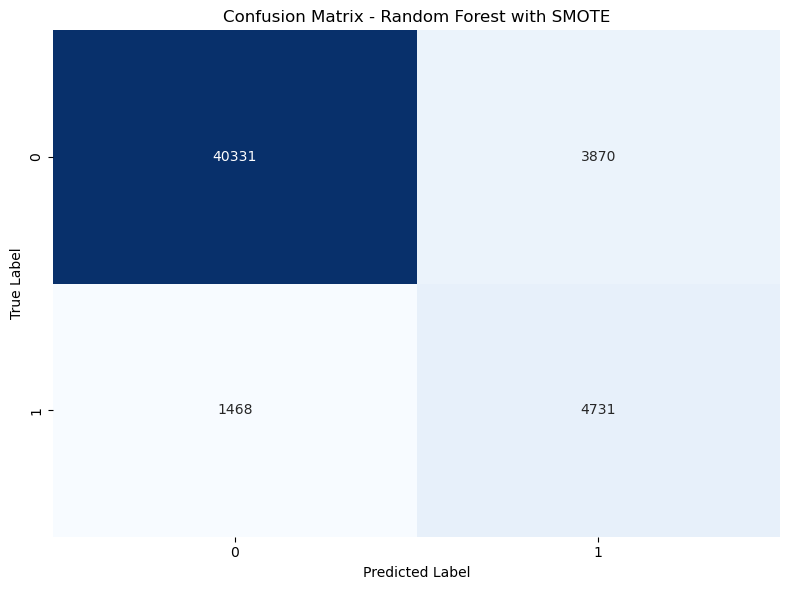

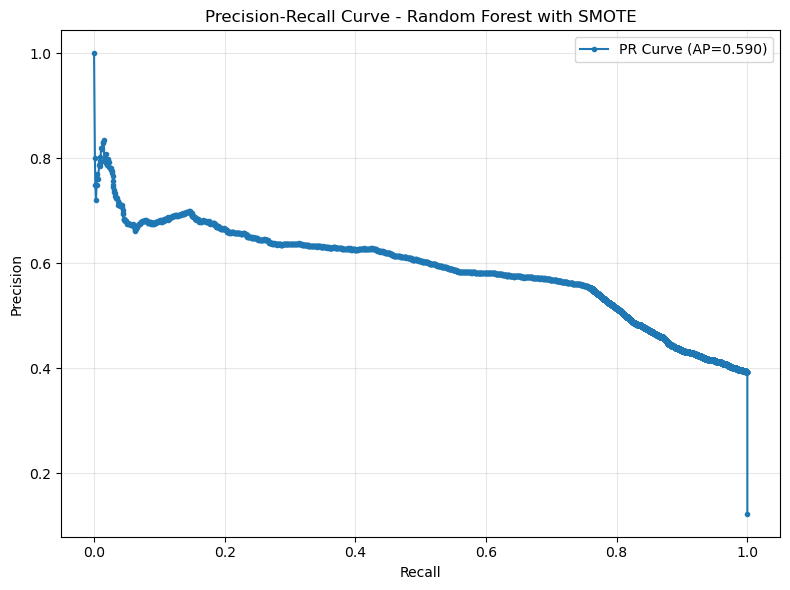


Testing strategy: SMOTEENN

Random Forest with SMOTEENN Performance:
Accuracy: 0.8753
ROC AUC: 0.8922
Average Precision (PR AUC): 0.4960
F1 Score: 0.5268
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     44201
           1       0.49      0.56      0.53      6199

    accuracy                           0.88     50400
   macro avg       0.72      0.74      0.73     50400
weighted avg       0.88      0.88      0.88     50400



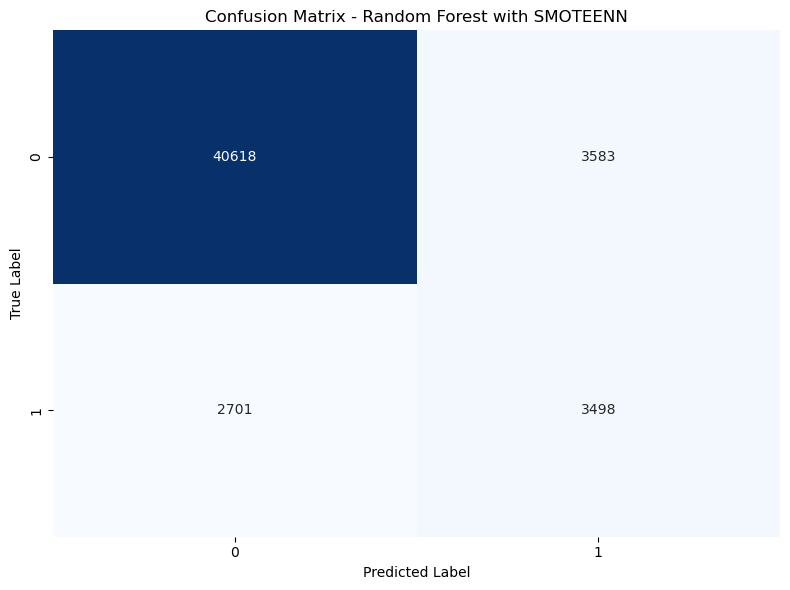

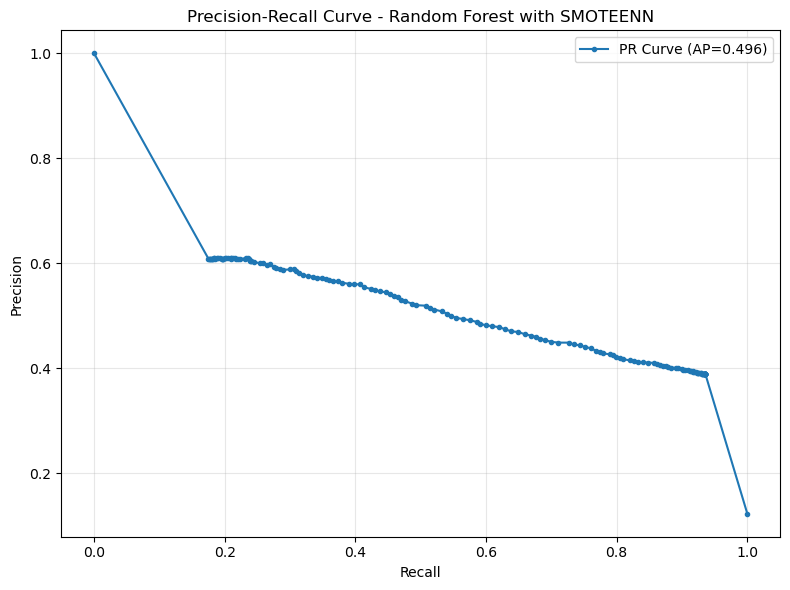


Testing strategy: SMOTETomek

Random Forest with SMOTETomek Performance:
Accuracy: 0.8941
ROC AUC: 0.9372
Average Precision (PR AUC): 0.5902
F1 Score: 0.6394
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



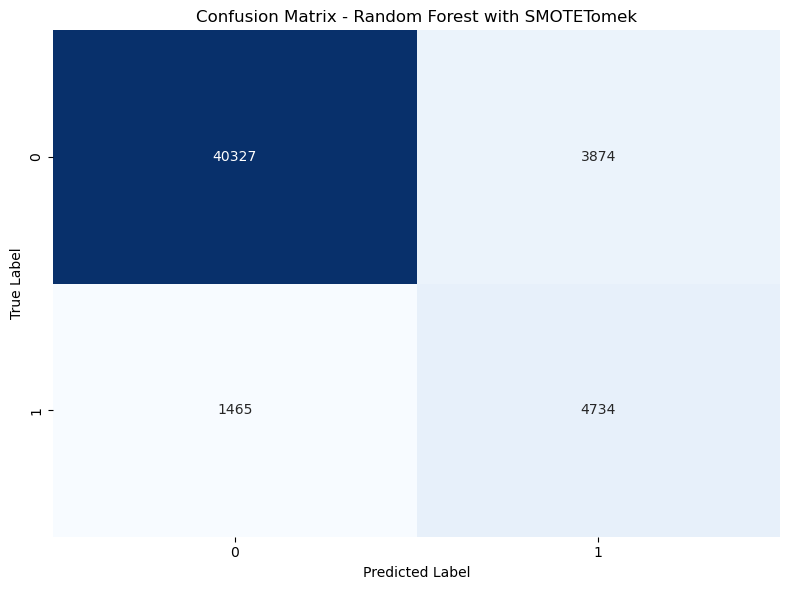

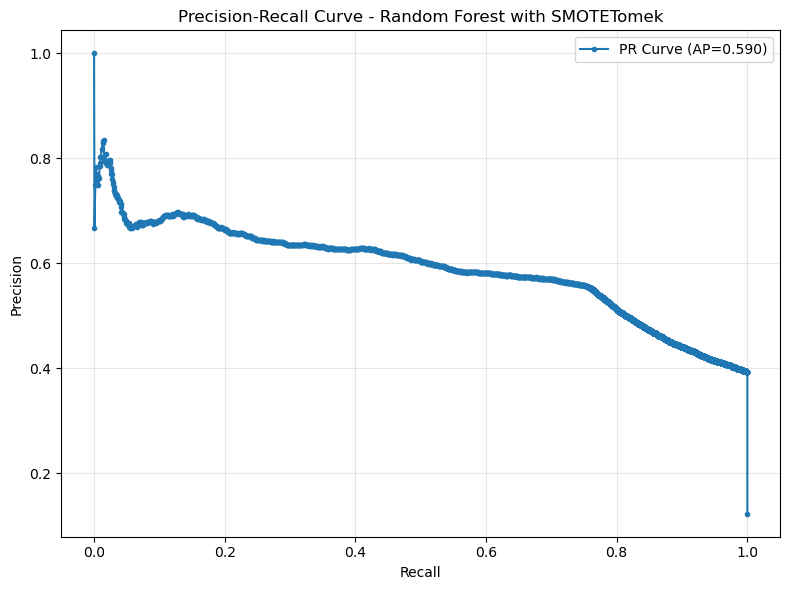


Testing strategy: Random Under-Sampling

Random Forest with Random Under-Sampling Performance:
Accuracy: 0.8802
ROC AUC: 0.9332
Average Precision (PR AUC): 0.5552
F1 Score: 0.6217
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     44201
           1       0.51      0.80      0.62      6199

    accuracy                           0.88     50400
   macro avg       0.74      0.85      0.78     50400
weighted avg       0.91      0.88      0.89     50400



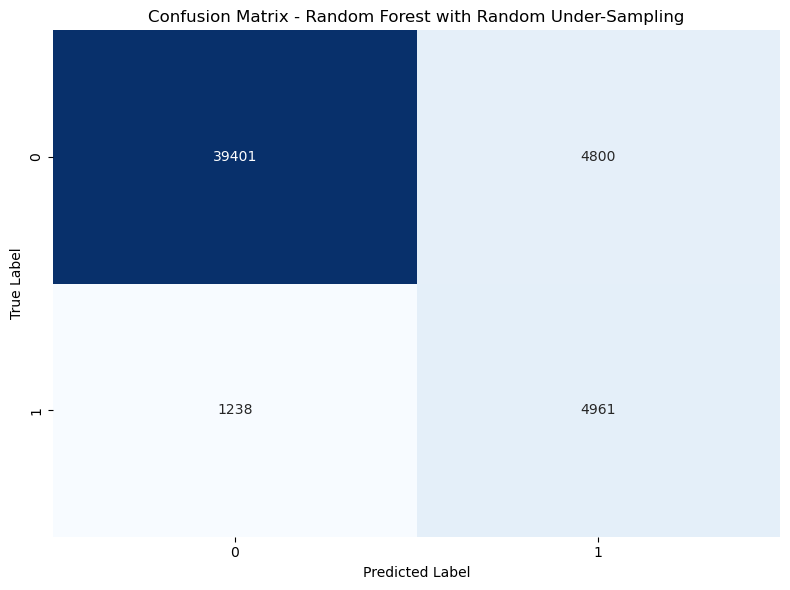

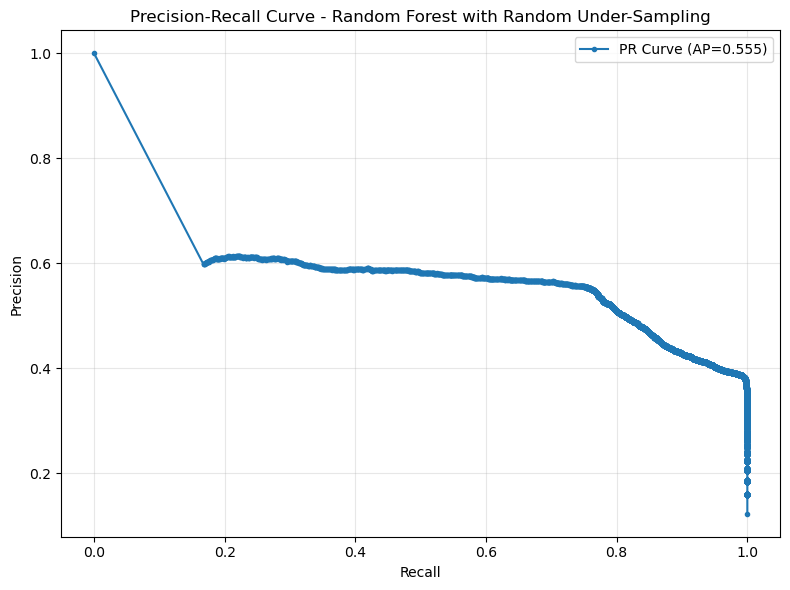


Testing strategy: Hybrid

Random Forest with Hybrid Performance:
Accuracy: 0.8929
ROC AUC: 0.9367
Average Precision (PR AUC): 0.5823
F1 Score: 0.6376
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     44201
           1       0.55      0.77      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



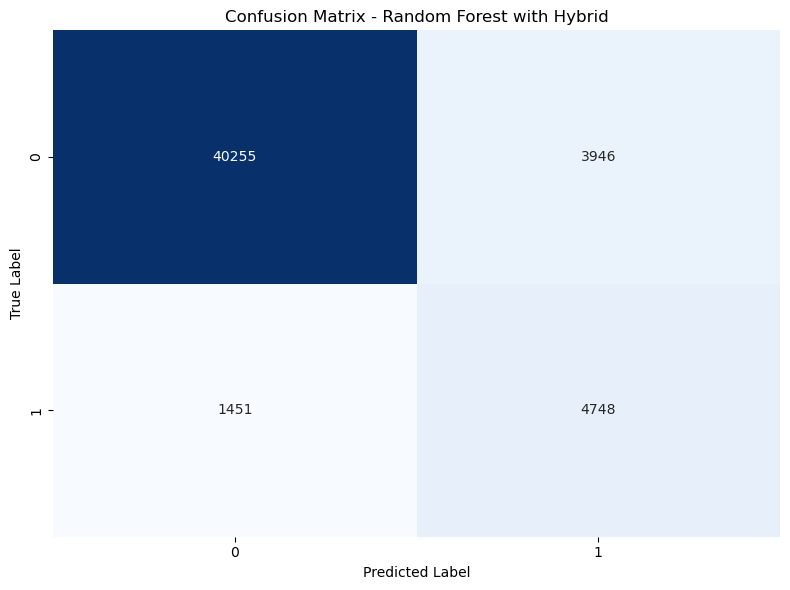

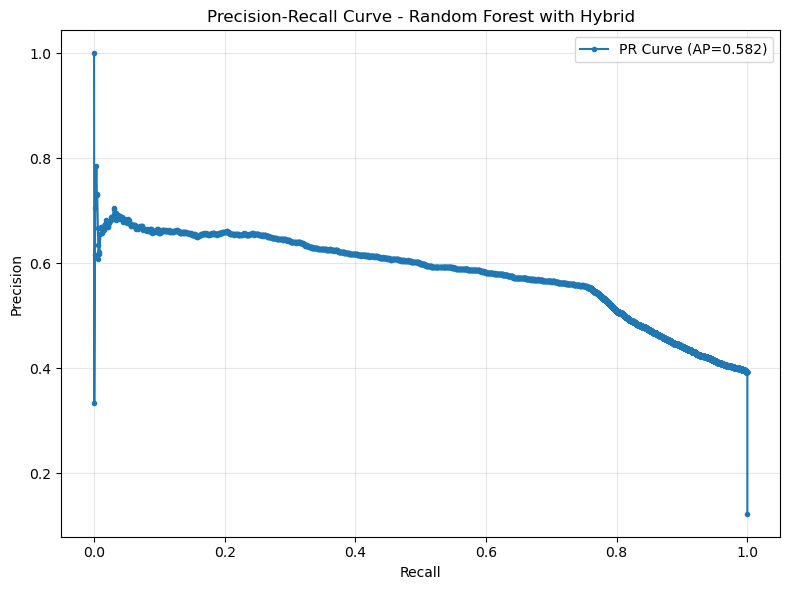


Best resampling strategy: No Resampling
PR AUC: 0.5913
ROC AUC: 0.9373
F1 Score: 0.6408

Tuning classifier: Random Forest
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Tuned Random Forest with No Resampling Performance:
Accuracy: 0.8948
ROC AUC: 0.9369
Average Precision (PR AUC): 0.5908
F1 Score: 0.6409
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400



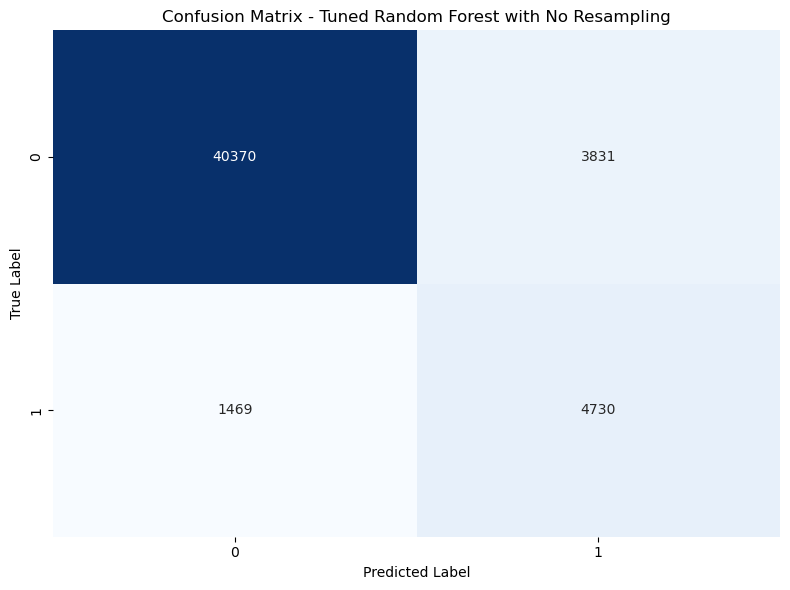

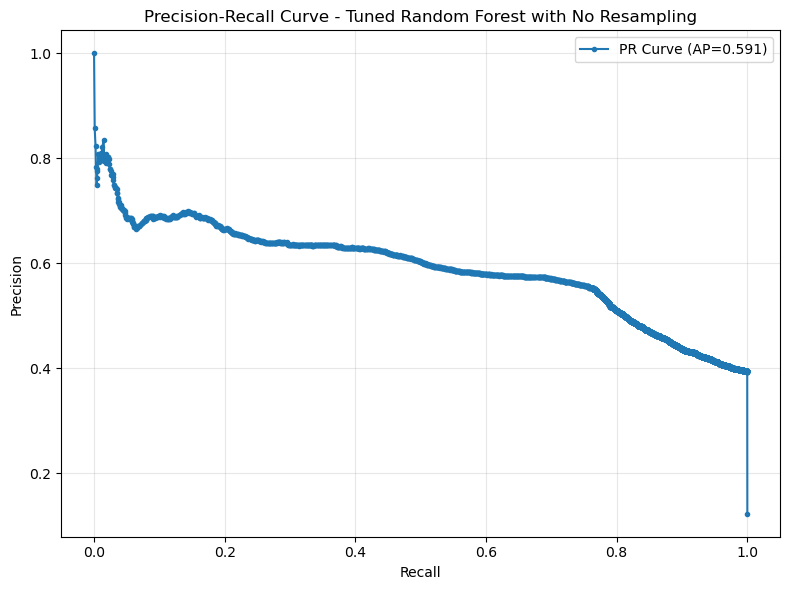


Best parameters for Random Forest:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced_subsample'}
Best CV scores:
  ROC AUC: 0.9387
  PR AUC: 0.6010
  F1: 0.6469

Tuning classifier: Gradient Boosting
Fitting 5 folds for each of 15 candidates, totalling 75 fits


KeyboardInterrupt: 

In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve, average_precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.calibration import CalibratedClassifierCV

# Set random seed for reproducibility
np.random.seed(42)

# Assuming df_train is already defined with your data
# Split features and target
X = df_train.drop('Risk_Flag', axis=1)
y = df_train['Risk_Flag']

# Identify categorical and numerical features
cat_features = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 
                'CITY', 'STATE', 'age_group', 'income_segment']
num_features = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 
                'job_stability', 'home_stability', 'financial_stability']

# Create preprocessing pipeline with more robust handling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='passthrough'
)

# Split the data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create a function to evaluate models with additional metrics focusing on imbalanced data
def evaluate_imbalanced_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    average_precision = average_precision_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    
    # Print results
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Average Precision (PR AUC): {average_precision:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    # Plot precision-recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='.', label=f'PR Curve (AP={average_precision:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return model, {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'pr_auc': average_precision,
        'f1': f1,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Try different resampling strategies
resampling_strategies = {
    'No Resampling': None,
    'SMOTE': SMOTE(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'Random Under-Sampling': RandomUnderSampler(random_state=42),
    'Hybrid': [SMOTE(random_state=42, sampling_strategy=0.5), 
               RandomUnderSampler(random_state=42, sampling_strategy=0.8)]
}

# Create and test resampled models with Random Forest
results = {}
for name, resampler in resampling_strategies.items():
    print(f"\n{'='*50}")
    print(f"Testing strategy: {name}")
    print(f"{'='*50}")
    
    # Create pipeline with preprocessing and resampling
    if name == 'Hybrid':
        steps = [('preprocessor', preprocessor)]
        for i, res in enumerate(resampler):
            steps.append((f'resampler_{i}', res))
        steps.append(('classifier', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42
        )))
        pipeline = ImbPipeline(steps=steps)
    elif resampler is not None:
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('resampler', resampler),
            ('classifier', RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=42
            ))
        ])
    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=42
            ))
        ])
    
    # Evaluate model
    model, metrics = evaluate_imbalanced_model(
        pipeline, X_train, X_test, y_train, y_test, 
        model_name=f"Random Forest with {name}"
    )
    results[name] = {'model': model, 'metrics': metrics}

# Select the best resampling strategy based on PR AUC (for imbalanced data)
best_strategy = max(results, key=lambda x: results[x]['metrics']['pr_auc'])
print(f"\nBest resampling strategy: {best_strategy}")
print(f"PR AUC: {results[best_strategy]['metrics']['pr_auc']:.4f}")
print(f"ROC AUC: {results[best_strategy]['metrics']['roc_auc']:.4f}")
print(f"F1 Score: {results[best_strategy]['metrics']['f1']:.4f}")

# Use the best resampling strategy for final model tuning
if best_strategy == 'Hybrid':
    steps = [('preprocessor', preprocessor)]
    for i, res in enumerate(resampling_strategies[best_strategy]):
        steps.append((f'resampler_{i}', res))
    best_pipeline = ImbPipeline(steps=steps)
elif resampling_strategies[best_strategy] is not None:
    best_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('resampler', resampling_strategies[best_strategy])
    ])
else:
    best_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor)
    ])

# Test different classifier options with the best resampling strategy
classifiers = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Hyperparameter grids for each classifier
param_grids = {
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 15, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__class_weight': ['balanced', 'balanced_subsample', None]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7, 9],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__subsample': [0.7, 0.8, 0.9, 1.0]
    },
    'Logistic Regression': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2', 'elasticnet'],
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0],
        'classifier__class_weight': ['balanced', None]
    }
}

# Train and evaluate each classifier
classifier_results = {}
for name, classifier in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Tuning classifier: {name}")
    print(f"{'='*50}")
    
    # Add classifier to pipeline
    if best_strategy == 'Hybrid' or resampling_strategies[best_strategy] is not None:
        pipeline = ImbPipeline(steps=list(best_pipeline.steps) + [('classifier', classifier)])
    else:
        pipeline = Pipeline(steps=list(best_pipeline.steps) + [('classifier', classifier)])
    
    # Set up RandomizedSearchCV with stratified k-fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Use RandomizedSearchCV for more efficient hyperparameter tuning
    grid_search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=15,  # Number of parameter settings sampled
        scoring=['roc_auc', 'average_precision', 'f1'],
        refit='average_precision',  # Optimize for PR AUC
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Perform search
    grid_search.fit(X_train, y_train)
    
    # Get the best model
    best_model = grid_search.best_estimator_
    
    # Evaluate best model
    model, metrics = evaluate_imbalanced_model(
        best_model, X_train, X_test, y_train, y_test, 
        model_name=f"Tuned {name} with {best_strategy}"
    )
    
    # Print best parameters
    print(f"\nBest parameters for {name}:")
    print(grid_search.best_params_)
    print(f"Best CV scores:")
    print(f"  ROC AUC: {grid_search.cv_results_['mean_test_roc_auc'][grid_search.best_index_]:.4f}")
    print(f"  PR AUC: {grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_]:.4f}")
    print(f"  F1: {grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]:.4f}")
    
    # Store results
    classifier_results[name] = {
        'model': model,
        'metrics': metrics,
        'params': grid_search.best_params_,
        'cv_results': {
            'roc_auc': grid_search.cv_results_['mean_test_roc_auc'][grid_search.best_index_],
            'pr_auc': grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_],
            'f1': grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]
        }
    }

# Select the best overall model
best_model_name = max(classifier_results, key=lambda x: classifier_results[x]['metrics']['pr_auc'])
final_model = classifier_results[best_model_name]['model']

print(f"\n{'='*50}")
print(f"Best Overall Model: {best_model_name} with {best_strategy}")
print(f"PR AUC: {classifier_results[best_model_name]['metrics']['pr_auc']:.4f}")
print(f"ROC AUC: {classifier_results[best_model_name]['metrics']['roc_auc']:.4f}")
print(f"F1 Score: {classifier_results[best_model_name]['metrics']['f1']:.4f}")
print(f"{'='*50}")

# Calibrate probabilities for the best model (optional but recommended)
# This ensures predicted probabilities are well-calibrated
try:
    print("\nCalibrating probabilities for the best model...")
    calibrated_model = CalibratedClassifierCV(final_model, cv=5, method='isotonic')
    calibrated_model.fit(X_train, y_train)
    
    # Evaluate calibrated model
    calibrated_model, calibrated_metrics = evaluate_imbalanced_model(
        calibrated_model, X_train, X_test, y_train, y_test, 
        model_name=f"Calibrated {best_model_name} with {best_strategy}"
    )
    
    # Compare original vs calibrated probabilities
    plt.figure(figsize=(10, 6))
    plt.hist(classifier_results[best_model_name]['metrics']['y_pred_proba'], bins=20, 
             alpha=0.5, label='Original')
    plt.hist(calibrated_metrics['y_pred_proba'], bins=20, 
             alpha=0.5, label='Calibrated')
    plt.title('Probability Distribution Comparison')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Use calibrated model as final model if it performs better
    if calibrated_metrics['pr_auc'] > classifier_results[best_model_name]['metrics']['pr_auc']:
        final_model = calibrated_model
        print("Using calibrated model for final predictions (better performance)")
    else:
        print("Using original model for final predictions (better performance)")
except Exception as e:
    print(f"Skipping calibration due to error: {e}")

# Feature importance analysis for the final model (if it's a tree-based model)
if hasattr(final_model, 'named_steps') and hasattr(final_model.named_steps.get('classifier', None), 'feature_importances_'):
    # Extract feature names
    preprocessor_fitted = final_model.named_steps['preprocessor']
    feature_names = []
    
    for name, trans, features in preprocessor_fitted.transformers_:
        if name == 'num':
            feature_names.extend(features)
        elif name == 'cat':
            # Get one-hot encoded feature names
            for i, feature in enumerate(features):
                categories = trans.categories_[i]
                feature_names.extend([f"{feature}_{c}" for c in categories])
    
    # Get feature importances
    importances = final_model.named_steps['classifier'].feature_importances_
    
    # Match feature names with importances
    if len(feature_names) == len(importances):
        # Create a DataFrame of feature importances
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        # Plot the top 20 features
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
        plt.title('Top 20 Feature Importances')
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 most important features:")
        print(feature_importance_df.head(10))

# Save the final model
import joblib
joblib.dump(final_model, 'improved_risk_prediction_model.pkl')
print("\nImproved model saved as 'improved_risk_prediction_model.pkl'")

# Function to make predictions with optimal threshold
def predict_with_optimal_threshold(model, X, threshold=0.5):
    """
    Make predictions using an optimal threshold based on F1-score or custom metric
    """
    y_pred_proba = model.predict_proba(X)[:, 1]
    return (y_pred_proba >= threshold).astype(int), y_pred_proba

# Find optimal threshold on validation data
print("\nFinding optimal threshold for predictions...")
# Create a validation set from training data
X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=43, stratify=y_train)

# Fit model on new training data
final_model.fit(X_train_new, y_train_new)

# Get predictions on validation data
val_probas = final_model.predict_proba(X_val)[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []
precision_scores = []
recall_scores = []

from sklearn.metrics import precision_score, recall_score

for threshold in thresholds:
    y_pred = (val_probas >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    
    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)

# Plot threshold vs metrics
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, 'b-', label='F1 Score')
plt.plot(thresholds, precision_scores, 'g-', label='Precision')
plt.plot(thresholds, recall_scores, 'r-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs. Threshold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Find optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.2f} (F1: {f1_scores[optimal_idx]:.4f})")

# Make final predictions using optimal threshold
final_predictions, final_probas = predict_with_optimal_threshold(final_model, X_test, threshold=optimal_threshold)

# Evaluate with optimal threshold
print("\nFinal Model Performance with Optimal Threshold:")
print(f"Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test, final_predictions):.4f}")
print(f"Classification Report:\n{classification_report(y_test, final_predictions)}")

# Plot final confusion matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Final Confusion Matrix with Optimal Threshold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Re-train the model on the entire training set
final_model.fit(X_train, y_train)

# Save the final model with optimal threshold info
final_model_info = {
    'model': final_model,
    'optimal_threshold': optimal_threshold,
    'preprocessing': preprocessor,
    'resampling_strategy': best_strategy
}
joblib.dump(final_model_info, 'final_risk_model_with_threshold.pkl')
print(f"\nFinal model with threshold information saved as 'final_risk_model_with_threshold.pkl'")

# Function to use the model in production
def predict_risk(model_info, new_data):
    """
    Function to make predictions on new data
    
    Parameters:
    model_info (dict): Dictionary containing model, threshold, and preprocessing info
    new_data (pd.DataFrame): New data to predict on
    
    Returns:
    tuple: (binary predictions, probability predictions)
    """
    model = model_info['model']
    threshold = model_info['optimal_threshold']
    
    # Get probability predictions
    probas = model.predict_proba(new_data)[:, 1]
    
    # Apply threshold
    predictions = (probas >= threshold).astype(int)
    
    return predictions, probas

print("\nExample usage for production:")
print("""
# Load the model
import joblib
model_info = joblib.load('final_risk_model_with_threshold.pkl')

# Make predictions on new data
predictions, probabilities = predict_risk(model_info, new_data)
""")

In [47]:
df_train.head()

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,age_group,job_stability,home_stability,financial_stability,income_segment
0,1303834,23,3,single,rented,no,mechanical_engineer,rewa,madhya_pradesh,3,13,0,middle age,0.130435,0.565217,651917.0,low
1,7574516,40,10,single,rented,no,software_developer,parbhani,maharashtra,9,13,0,old,0.225000,0.325000,3787258.0,high
2,3991815,66,4,married,rented,no,technical_writer,alappuzha,kerala,4,10,0,old,0.060606,0.151515,1995907.5,medium
3,6256451,41,2,single,rented,yes,software_developer,bhubaneswar,odisha,2,12,1,old,0.048780,0.292683,6256451.0,medium
4,5768871,47,11,single,rented,no,civil_servant,tiruchirappalli,tamil_nadu,3,14,1,old,0.063830,0.297872,2884435.5,medium


In [53]:
unique_values = {col: df_train[col].unique() for col in df_train.columns}
unique_values

{'Income': array([1303834, 7574516, 3991815, ..., 2843572, 4522448, 9070230]),
 'Age': array([23, 40, 66, 41, 47, 64, 58, 33, 24, 78, 22, 28, 57, 48, 39, 71, 56,
        54, 50, 72, 36, 76, 38, 31, 52, 59, 21, 26, 55, 45, 77, 63, 30, 25,
        73, 75, 27, 74, 67, 46, 68, 79, 42, 60, 32, 65, 49, 35, 61, 29, 37,
        69, 62, 53, 70, 34, 43, 44, 51]),
 'Experience': array([ 3, 10,  4,  2, 11,  0, 14, 17, 12,  7,  9,  6,  8,  1, 13, 19, 15,
        20,  5, 16, 18]),
 'Married/Single': array(['single', 'married'], dtype=object),
 'House_Ownership': array(['rented', 'norent_noown', 'owned'], dtype=object),
 'Car_Ownership': array(['no', 'yes'], dtype=object),
 'Profession': array(['mechanical_engineer', 'software_developer', 'technical_writer',
        'civil_servant', 'librarian', 'economist', 'flight_attendant',
        'architect', 'designer', 'physician', 'financial_analyst',
        'air_traffic_controller', 'politician', 'police_officer', 'artist',
        'surveyor', 'design_engi

In [56]:
df_train.describe()

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,job_stability,home_stability,financial_stability
count,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000,2.520000e+05
mean,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000,0.145674,0.276441,3.337686e+06
std,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438,0.107368,0.118069,2.618890e+06
min,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.126582,0.000000e+00
25%,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000,0.068182,0.184615,1.391540e+06
50%,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000,0.122449,0.239130,2.940425e+06
75%,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000,0.195122,0.342105,4.470476e+06
max,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000,0.666667,0.666667,1.999389e+07


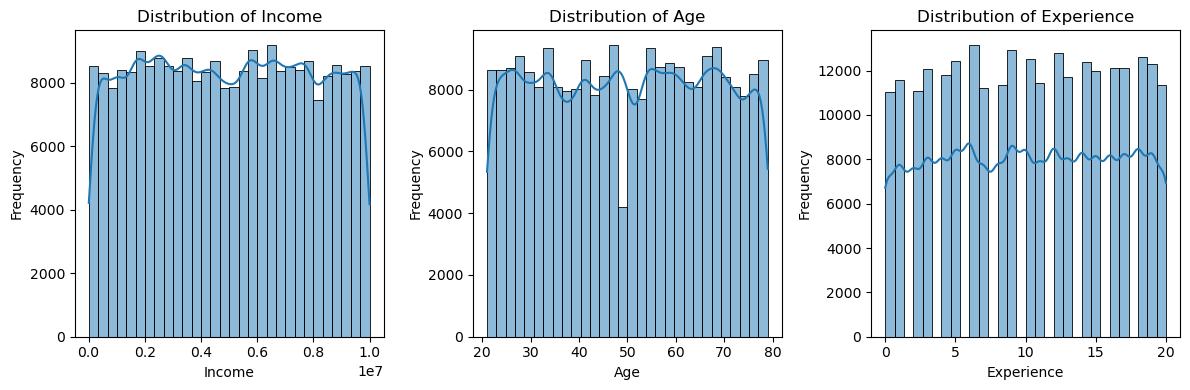

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_train is already loaded
columns_to_plot = ['Income', 'Age', 'Experience']

# Set the figure size
plt.figure(figsize=(12, 4))

# Loop through the columns and create histograms
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_train[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()
